# Análise dos Resultados

Análise exploratória com filtro **≥50% de zeros** no SVI:
remove tickers com 50% ou mais das semanas com SVI = 0.

Requer `previsoes_consolidadas.csv` gerado por `02_modelos.R` (M0–M3, painel alinhado).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch.bootstrap import MCS

CAMINHO = "./data/"

NOMES = {
    "qlike_m0": "M0 (RW)",
    "qlike_m1": "M1 (GARCH)",
    "qlike_m2": "M2 (GARCH-X ΔSVI)",
    "qlike_m3": "M3 (GARCH-X log-dev)",
}


In [2]:
# ── Carrega dados ────────────────────────────────────────────────
df_previsoes    = pd.read_csv(CAMINHO + "previsoes_consolidadas.csv", parse_dates=["semana"])
df_acoes        = pd.read_csv(CAMINHO + "acoes_elegiveis.csv")
df_final        = pd.read_csv(CAMINHO + "base_final_tcc.csv",        parse_dates=["semana"])
df_resumo_params = pd.read_csv(CAMINHO + "resumo_parametros.csv").set_index("ticker_b3")
df_trends       = pd.read_csv(CAMINHO + "google_trends_svi.csv",     parse_dates=["semana"])

# ── Proporção de zeros no SVI ─────────────────────────────────────
zeros_pct = df_trends.groupby("ticker_b3")["svi"].apply(lambda x: (x == 0).mean())
df_resumo_params["svi_zeros_pct"] = zeros_pct

In [ ]:
# ── QLIKE ────────────────────────────────────────────────────────
def qlike(rv, pred):
    mask = (rv > 0) & (pred > 0)
    r    = np.where(mask, rv / pred, np.nan)
    return np.where(mask, r - np.log(r) - 1, np.nan)

# ── Tickers com erro de singular matrix (global) ─────────────────
tickers_erro_m2 = df_previsoes[df_previsoes["rv_pred_m2"].isna()]["ticker_b3"].unique()
tickers_erro_m3 = df_previsoes[df_previsoes["rv_pred_m3"].isna()]["ticker_b3"].unique()
tickers_erro_global = np.union1d(tickers_erro_m2, tickers_erro_m3)

# ── Função genérica por cenário ───────────────────────────────────
def rodar_cenario(df_prev, threshold_zeros=None, label=""):
    """
    Roda QLIKE + MCS para um filtro de zeros.
    threshold_zeros: mantém tickers onde pct_zeros < threshold (None = sem filtro).
    """
    df_sub = df_prev.copy()

    # Aplica filtro de zeros
    if threshold_zeros is not None:
        tickers_ok = zeros_pct[zeros_pct < threshold_zeros].index
        df_sub = df_sub[df_sub["ticker_b3"].isin(tickers_ok)]

    # Remove singular matrix
    df_sub = df_sub[~df_sub["ticker_b3"].isin(tickers_erro_global)]
    n_tickers = df_sub["ticker_b3"].nunique()

    df_oos_sub = df_sub.query("split == 'out-of-sample'").copy()
    df_oos_sub["qlike_m0"] = qlike(df_oos_sub["rv"].values, df_oos_sub["rv_pred_m0"].values)
    df_oos_sub["qlike_m1"] = qlike(df_oos_sub["rv"].values, df_oos_sub["rv_pred_m1"].values)
    df_oos_sub["qlike_m2"] = qlike(df_oos_sub["rv"].values, df_oos_sub["rv_pred_m2"].values)
    df_oos_sub["qlike_m3"] = qlike(df_oos_sub["rv"].values, df_oos_sub["rv_pred_m3"].values)

    oos_losses = (
        df_oos_sub[list(NOMES)]
        .dropna()
        .rename(columns=NOMES)
        .reset_index(drop=True)
    )

    mcs_obj = MCS(oos_losses, size=0.10, block_size=5, reps=1000, seed=42)
    mcs_obj.compute()

    print(f"\n{'═'*60}")
    print(f"  {label}")
    print(f"  Tickers: {n_tickers} | Obs OOS: {len(oos_losses)}")
    print(f"{'═'*60}")
    print("QLIKE médio:")
    print(oos_losses.mean().to_string())
    print(f"\nMCS (α=10%):")
    print(mcs_obj.pvalues.to_string())
    print(f"\nConjunto de confiança : {list(mcs_obj.included)}")
    print(f"Excluídos             : {list(mcs_obj.excluded)}")

    return mcs_obj, df_oos_sub

# ── Cenário 1: Todos os tickers (sem filtro zeros) ────────────────
mcs1, df_oos1 = rodar_cenario(
    df_previsoes,
    threshold_zeros=None,
    label="1. Todos os tickers (sem filtro zeros)"
)

# ── Cenário 2: ≥50% de SVI diferente de zero ─────────────────────
mcs2, df_oos2 = rodar_cenario(
    df_previsoes,
    threshold_zeros=0.50,
    label="2. Tickers com ≥50% de SVI ≠ 0"
)

# ── Cenário 3: ≥70% de SVI diferente de zero ─────────────────────
mcs3, df_oos3 = rodar_cenario(
    df_previsoes,
    threshold_zeros=0.30,
    label="3. Tickers com ≥70% de SVI ≠ 0"
)

# ── Salva todos os tickers (cenário 1) como CSVs principais ──────
df_oos   = df_oos1.copy()
df_qlike = (
    df_oos
    .groupby("ticker_b3")[list(NOMES)]
    .mean()
    .rename(columns=NOMES)
)
df_mcs_principal = (
    mcs1.pvalues
    .rename(columns={"Pvalue": "p_valor"})
    .assign(no_conjunto=lambda d: d["p_valor"] >= 0.10)
    .sort_values("p_valor", ascending=False)
)
df_qlike.to_csv(CAMINHO + "qlike_por_ticker.csv")
df_mcs_principal.to_csv(CAMINHO + "mcs_resultado.csv")

# ── Resumo γ ──────────────────────────────────────────────────────
n_sig = (df_resumo_params["pct_signif_5pct"] >= 50).sum()
print(f"\nγ M2 (ΔSVI) significativo em ≥50% das janelas:")
print(f"  {n_sig}/{len(df_resumo_params)} tickers")
print("\nTop 5 M2 por % de janelas significativas:")
print(df_resumo_params["pct_signif_5pct"].sort_values(ascending=False).head().to_string())

n_sig_m3 = (df_resumo_params["pct_signif_5pct_m3"] >= 50).sum()
print(f"\nγ M3 (log-dev) significativo em ≥50% das janelas:")
print(f"  {n_sig_m3}/{len(df_resumo_params)} tickers")
print("\nTop 5 M3 por % de janelas significativas:")
print(df_resumo_params["pct_signif_5pct_m3"].sort_values(ascending=False).head().to_string())


════════════════════════════════════════════════════════════
  1. Todos os tickers (sem filtro zeros)
  Tickers: 310 | Obs OOS: 29473
════════════════════════════════════════════════════════════
QLIKE médio:
M0 (RW)         62.792149
M1 (GARCH)       0.821409
M2 (GARCH-X)     0.836887

MCS (α=10%):
              Pvalue
Model name          
M2 (GARCH-X)    0.01
M0 (RW)         0.01
M1 (GARCH)      1.00

Conjunto de confiança : ['M1 (GARCH)']
Excluídos             : ['M0 (RW)', 'M2 (GARCH-X)']

════════════════════════════════════════════════════════════
  2. Tickers com ≥50% de SVI ≠ 0
  Tickers: 177 | Obs OOS: 18185
════════════════════════════════════════════════════════════
QLIKE médio:
M0 (RW)         1.761324
M1 (GARCH)      0.646316
M2 (GARCH-X)    0.663498

MCS (α=10%):
              Pvalue
Model name          
M0 (RW)        0.000
M2 (GARCH-X)   0.008
M1 (GARCH)     1.000

Conjunto de confiança : ['M1 (GARCH)']
Excluídos             : ['M0 (RW)', 'M2 (GARCH-X)']

══════════════

In [4]:
# ── Proporção de zeros no SVI ─────────────────────────────────────
zeros_pct = df_trends.groupby("ticker_b3")["svi"].apply(lambda x: (x == 0).mean())
df_resumo_params["svi_zeros_pct"] = zeros_pct.reindex(df_resumo_params.index)

float_cols = df_resumo_params.select_dtypes(include="float").columns
df_resumo_params[float_cols] = df_resumo_params[float_cols].round(4)

df_resumo_params.to_csv(CAMINHO + "apendice_resumo_params.csv")
df_resumo_params

,n_previsoes,gamma_medio,gamma_pval_medio,pct_signif_5pct,persistencia_m1,persistencia_m2,svi_zeros_pct
ticker_b3,,,,,,,
AALR3,103,0.2389,0.9029,9.7087,0.9814,1.0331,0.6552
ABCB4,103,0.0099,0.9524,3.8835,0.9909,0.9909,0.0000
ABEV3,103,0.1110,0.8162,17.4757,0.9394,0.9316,0.0000
AERI3,103,0.9962,0.6329,35.9223,0.9541,0.9273,0.0153
AFLT3,103,0.0000,1.0000,0.0000,0.9756,0.9885,0.9847
...,...,...,...,...,...,...,...
WHRL3,103,0.0000,1.0000,0.0000,0.9957,0.9966,0.9808
WHRL4,103,0.0780,0.6336,30.0971,0.9564,0.9739,0.8467
WIZC3,103,0.0030,0.9903,0.9709,0.9945,0.9944,0.3716


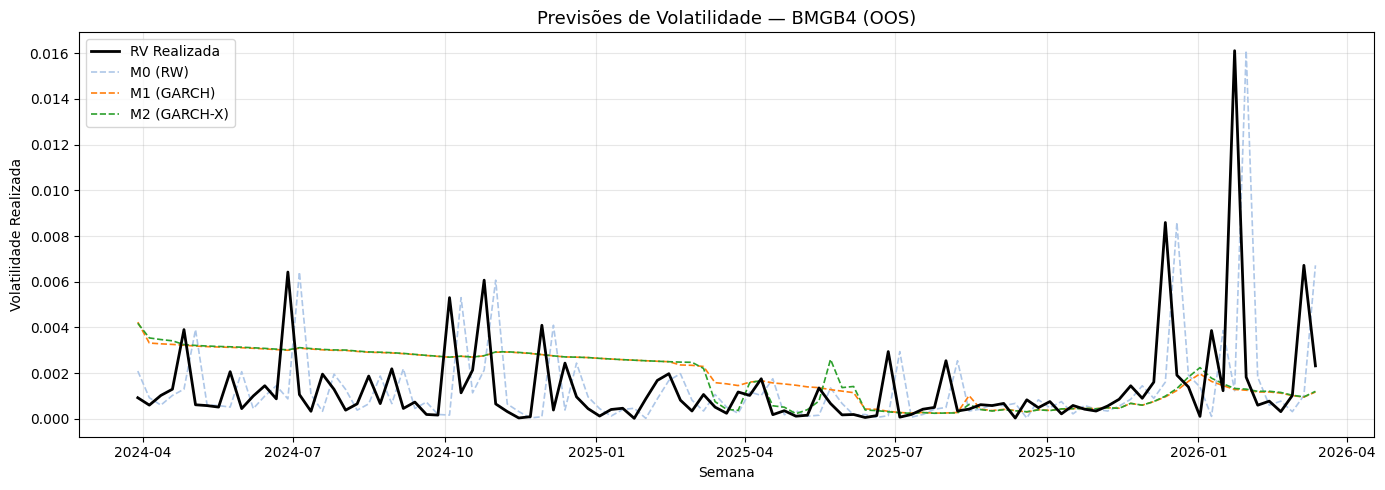

In [5]:
# ── Gráfico comparando as previsões ────────────────────────────────────────────────
TICKER = "BMGB4" 

df_graf = (
    df_previsoes
    .query("ticker_b3 == @TICKER and split == 'out-of-sample'")
    .sort_values("semana")
)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_graf["semana"], df_graf["rv"],         label="RV Realizada", color="black",   linewidth=2.0, zorder=5)
ax.plot(df_graf["semana"], df_graf["rv_pred_m0"], label="M0 (RW)",      color="#aec7e8", linewidth=1.2, linestyle="--")
ax.plot(df_graf["semana"], df_graf["rv_pred_m1"], label="M1 (GARCH)",   color="#ff7f0e", linewidth=1.2, linestyle="--")
ax.plot(df_graf["semana"], df_graf["rv_pred_m2"], label="M2 (GARCH-X ΔSVI)", color="#2ca02c", linewidth=1.2, linestyle="--")
ax.plot(df_graf["semana"], df_graf["rv_pred_m3"], label="M3 (GARCH-X log-dev)", color="#9467bd", linewidth=1.2, linestyle="--")

ax.set_title(f"Previsões de Volatilidade — {TICKER} (OOS)", fontsize=13)
ax.set_xlabel("Semana")
ax.set_ylabel("Volatilidade Realizada")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
from datetime import datetime

TXT = CAMINHO + "diagnostico_filtros.txt"

def gerar_bloco(df_prev, threshold_zeros=None, remove_singular=True, label=""):
    """Gera um bloco formatado para um cenário do diagnóstico."""
    sep = "═" * 60
    linhas = [f"\n{sep}", f"  {label}", sep]

    n_total        = df_prev["ticker_b3"].nunique()
    n_erros_global = len(tickers_erro_global)
    df_sub         = df_prev.copy()

    # Aplica filtro de zeros
    if threshold_zeros is not None:
        tickers_ok    = zeros_pct[zeros_pct < threshold_zeros].index
        df_sub        = df_sub[df_sub["ticker_b3"].isin(tickers_ok)]
        n_apos_filtro = df_sub["ticker_b3"].nunique()
        erros_filtro  = df_sub[df_sub["rv_pred_m2"].isna() | df_sub["rv_pred_m3"].isna()]["ticker_b3"].nunique()

    # Remove singular matrix
    if remove_singular:
        df_sub = df_sub[~df_sub["ticker_b3"].isin(tickers_erro_global)]

    n_final       = df_sub["ticker_b3"].nunique()
    tickers_finais = set(df_sub["ticker_b3"].unique())

    # QLIKE OOS
    df_oos_sub = df_sub.query("split == 'out-of-sample'").copy()
    df_oos_sub["qlike_m0"] = qlike(df_oos_sub["rv"].values, df_oos_sub["rv_pred_m0"].values)
    df_oos_sub["qlike_m1"] = qlike(df_oos_sub["rv"].values, df_oos_sub["rv_pred_m1"].values)
    df_oos_sub["qlike_m2"] = qlike(df_oos_sub["rv"].values, df_oos_sub["rv_pred_m2"].values)
    df_oos_sub["qlike_m3"] = qlike(df_oos_sub["rv"].values, df_oos_sub["rv_pred_m3"].values)

    oos_losses = (
        df_oos_sub[list(NOMES)]
        .dropna()
        .rename(columns=NOMES)
        .reset_index(drop=True)
    )
    n_usadas     = len(oos_losses)
    n_descartadas = len(df_oos_sub) - n_usadas

    # MCS
    mcs_obj = MCS(oos_losses, size=0.10, block_size=5, reps=1000, seed=42)
    mcs_obj.compute()

    df_mcs = (
        mcs_obj.pvalues
        .rename(columns={"Pvalue": "p_valor"})
        .assign(no_conjunto=lambda d: d["p_valor"] >= 0.10)
        .sort_values("p_valor", ascending=False)
    )

    # γ_SVI: significância do coeficiente γ nos tickers finais
    df_res = df_resumo_params[df_resumo_params.index.isin(tickers_finais)]
    n_sig  = int((df_res["pct_signif_5pct"] >= 50).sum())
    top5   = df_res["pct_signif_5pct"].sort_values(ascending=False).head(5)

    # Monta linhas
    linhas.append(f"  Tickers em df_previsoes              : {n_total}")
    linhas.append(f"  Com erro (M2)                        : {n_erros_global}")
    if threshold_zeros is not None:
        pct = int(threshold_zeros * 100)
        linhas.append(f"  Após filtro zeros ≥{pct}%              : {n_apos_filtro}  ({erros_filtro} com erro)")
    linhas.append(f"  Na comparação final                  : {n_final}")
    linhas.append(f"  Obs. OOS usadas / descartadas        : {n_usadas} / {n_descartadas}")

    linhas.append("\n  QLIKE médio:")
    for col in oos_losses.columns:
        linhas.append(f"    {col:<15}: {oos_losses[col].mean():.6f}")

    linhas.append("\n  MCS (α=10%):")
    for line in df_mcs.to_string().split("\n"):
        linhas.append(f"    {line}")

    linhas.append(f"\n  Conjunto de confiança : {list(mcs_obj.included)}")
    linhas.append(f"  Excluídos             : {list(mcs_obj.excluded)}")

    linhas.append("\n  γ_SVI (δ) significativo em ≥50% das janelas:")
    linhas.append(f"    {n_sig}/{n_final} tickers")
    linhas.append("\n  Top 5 por % de janelas significativas (γ_SVI):")
    linhas.append(top5.to_string())

    return "\n".join(linhas) + "\n"


# Gera os 4 cenários e salva
with open(TXT, "w", encoding="utf-8") as f:
    f.write(f"Diagnóstico — comparação de cenários\n")
    f.write(f"Gerado em: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

    cenarios = [
        (None,  True,  "1. Singular matrix removido (sem filtro zeros)"),
        (0.70,  True,  "2. Filtro ≥70% + singular matrix removido"),
        (0.50,  True,  "3. Filtro ≥50% + singular matrix removido"),
        (None,  False, "4. Sem filtro (NaN via .dropna())"),
    ]

    for threshold, remove_sing, label in cenarios:
        bloco = gerar_bloco(df_previsoes, threshold, remove_sing, label)
        print(bloco)
        f.write(bloco)

print(f"✓ Salvo em {TXT}")


════════════════════════════════════════════════════════════
  1. Singular matrix removido (sem filtro zeros)
════════════════════════════════════════════════════════════
  Tickers em df_previsoes              : 323
  Com erro (M2)                        : 13
  Na comparação final                  : 310
  Obs. OOS usadas / descartadas        : 29473 / 2457

  QLIKE médio:
    M0 (RW)        : 62.792149
    M1 (GARCH)     : 0.821409
    M2 (GARCH-X)   : 0.836887

  MCS (α=10%):
                  p_valor  no_conjunto
    Model name                        
    M1 (GARCH)       1.00         True
    M2 (GARCH-X)     0.01        False
    M0 (RW)          0.01        False

  Conjunto de confiança : ['M1 (GARCH)']
  Excluídos             : ['M0 (RW)', 'M2 (GARCH-X)']

  γ_SVI (δ) significativo em ≥50% das janelas:
    27/310 tickers

  Top 5 por % de janelas significativas (γ_SVI):
ticker_b3
ALUP3    95.1456
PATI4    90.9091
PINE4    90.2913
JFEN3    89.3204
CPLE3    83.4951


════════════

In [7]:
df_qlike["melhor"] = df_qlike[list(NOMES.values())].idxmin(axis=1)
print(df_qlike["melhor"].value_counts())

# Cruzar γ-significância com qual modelo vence por ticker
tickers_signif = df_resumo_params[df_resumo_params["pct_signif_5pct"] >= 50].index
# Filter tickers_signif to only include those present in df_qlike's index
tickers_signif = tickers_signif.intersection(df_qlike.index)
print(df_qlike.loc[tickers_signif, "melhor"].value_counts())

melhor
M1 (GARCH)      175
M2 (GARCH-X)    131
M0 (RW)           4
Name: count, dtype: int64
melhor
M1 (GARCH)      18
M2 (GARCH-X)     9
Name: count, dtype: int64


In [8]:
# ── Grupos ─────────────────────────────────────────────────────
tickers_m2_vence = df_qlike[df_qlike["melhor"] == "M2 (GARCH-X ΔSVI)"].index
tickers_m2_perde = df_qlike[df_qlike["melhor"] != "M2 (GARCH-X ΔSVI)"].index
tickers_todos    = df_qlike.index

# ── Volume financeiro (R$) — fonte correta ─────────────────────
vol = (
    df_acoes
    .assign(ticker_b3=lambda d: d["ticker_yf"].str.replace(".SA", "", regex=False))
    .groupby("ticker_b3")["vol_fin_medio"]
    .first()
)

# ── Zeros no SVI ───────────────────────────────────────────────
zeros_svi = (
    df_final.groupby("ticker_b3")["svi"]
    .apply(lambda x: (x == 0).mean() * 100)
)

# ── Setor via yfinance ─────────────────────────────────────────
print("⏳ Buscando setor...")
setores = {}
for t in tickers_todos:
    try:
        setores[t] = yf.Ticker(t + ".SA").info.get("sector", "N/D")
    except:
        setores[t] = "N/D"

# ── DataFrame base ─────────────────────────────────────────────
df_analise = df_qlike[["melhor"]].copy()
df_analise["grupo"]        = np.where(df_analise.index.isin(tickers_m2_vence), "M2 vence", "M2 perde")
df_analise["zeros_pct"]    = zeros_svi
df_analise["vol_fin_medio"] = vol
df_analise["setor"]        = pd.Series(setores)

df_analise["zeros_bucket"] = pd.cut(
    df_analise["zeros_pct"],
    bins=range(0, 110, 10), right=False,
    labels=[f"{i}-{i+10}%" for i in range(0, 100, 10)]
)
df_analise["vol_bucket"] = pd.cut(
    df_analise["vol_fin_medio"],
    bins=[0, 1e6, 10e6, 100e6, 500e6, float("inf")],
    labels=["<1M", "1-10M", "10-100M", "100-500M", ">500M"]
)

# ── Função para montar tabela comparativa ──────────────────────
def tabela_comparativa(coluna, titulo):
    tab = (
        df_analise.groupby([coluna, "grupo"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=["M2 perde", "M2 vence"], fill_value=0)
    )
    tab["Total"] = tab.sum(axis=1)
    tab.index.name = "Métrica"
    tab.columns.name = None
    print(f"\n{'═'*55}")
    print(f"  {titulo}")
    print(f"{'═'*55}")
    print(tab.to_string())

# ── Tabelas ────────────────────────────────────────────────────
tabela_comparativa("zeros_bucket", "1. Zeros no SVI")
tabela_comparativa("vol_bucket",   "2. Volume financeiro médio (R$)")
tabela_comparativa("setor",        "3. Setor")

# ── Mediana do volume por grupo ────────────────────────────────
print("\n  Mediana volume financeiro por grupo:")
print(
    df_analise.groupby("grupo")["vol_fin_medio"]
    .median()
    .apply(lambda x: f"R$ {x:,.0f}")
    .to_string()
)

⏳ Buscando setor...

═══════════════════════════════════════════════════════
  1. Zeros no SVI
═══════════════════════════════════════════════════════
         M2 perde  M2 vence  Total
Métrica                           
0-10%          87        52    139
10-20%          6        10     16
20-30%          7         1      8
30-40%          4         7     11
40-50%          1         2      3
50-60%          6         0      6
60-70%         12         7     19
70-80%          6         5     11
80-90%          6         9     15
90-100%        44        38     82

═══════════════════════════════════════════════════════
  2. Volume financeiro médio (R$)
═══════════════════════════════════════════════════════
          M2 perde  M2 vence  Total
Métrica                            
<1M             66        55    121
1-10M           39        33     72
10-100M         44        30     74
100-500M        26        11     37
>500M            4         2      6

═════════════════════════════

In [9]:
print(df_analise[df_analise["vol_bucket"] == ">500M"][["grupo", "vol_fin_medio"]].sort_values("vol_fin_medio", ascending=False))
print(df_analise.groupby("grupo")["zeros_pct"].median())

              grupo  vol_fin_medio
ticker_b3                         
PDGR3      M2 perde   3.848395e+10
VALE3      M2 vence   1.486093e+09
PETR4      M2 vence   1.210975e+09
ITUB4      M2 perde   7.717210e+08
MGLU3      M2 perde   7.233544e+08
BBDC4      M2 perde   5.608905e+08
grupo
M2 perde    11.969112
M2 vence    32.046332
Name: zeros_pct, dtype: float64


In [10]:
# Verificar PDGR3 no df_acoes
print(df_acoes[df_acoes["ticker_yf"] == "PDGR3.SA"])

# E no df_final para ver o volume semanal
print(df_final[df_final["ticker_b3"] == "PDGR3"][["semana", "volume_total", "preco_fechamento"]].describe())

    ticker_yf  dias  vol_fin_medio
215  PDGR3.SA  1243   3.848395e+10
                    semana  volume_total  preco_fechamento
count                  259  2.590000e+02      2.590000e+02
mean   2023-09-22 00:00:00  8.959348e+04      1.984445e+06
min    2021-04-02 00:00:00  0.000000e+00      8.500000e-01
25%    2022-06-27 12:00:00  0.000000e+00      2.500000e+02
50%    2023-09-22 00:00:00  4.500000e+01      9.675000e+04
75%    2024-12-16 12:00:00  5.278000e+03      2.562500e+06
max    2026-03-13 00:00:00  4.291900e+06      1.812500e+07
std                    NaN  4.412690e+05      3.954544e+06


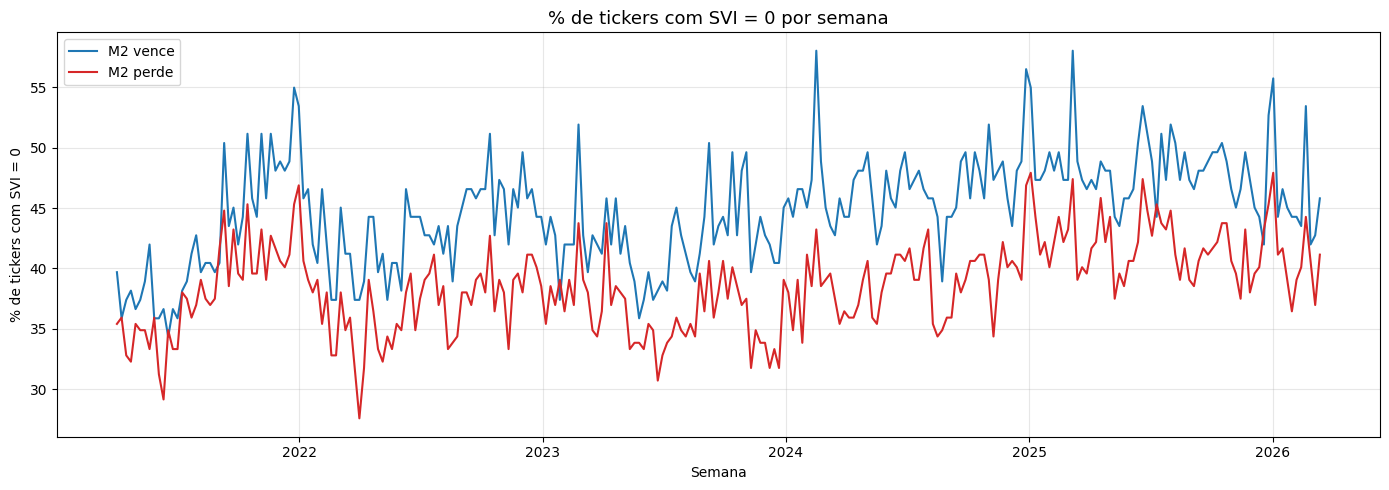

In [11]:
import matplotlib.pyplot as plt

# % de tickers com svi=0 por semana, separado por grupo
df_final["grupo"] = np.where(
    df_final["ticker_b3"].isin(tickers_m2_vence), "M2 vence", "M2 perde"
)

zeros_semana = (
    df_final.groupby(["semana", "grupo"])
    .apply(lambda x: (x["svi"] == 0).mean() * 100)
    .reset_index(name="pct_zeros")
)

fig, ax = plt.subplots(figsize=(14, 5))

for grupo, cor in [("M2 vence", "#1f77b4"), ("M2 perde", "#d62728")]:
    d = zeros_semana[zeros_semana["grupo"] == grupo]
    ax.plot(d["semana"], d["pct_zeros"], label=grupo, color=cor, linewidth=1.5)

ax.set_title("% de tickers com SVI = 0 por semana", fontsize=13)
ax.set_xlabel("Semana")
ax.set_ylabel("% de tickers com SVI = 0")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()